In [27]:
# Imports
import os
import time
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import Counter
from joblib import dump, load

# Métricas e ferramentas de Machine Learning
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn import preprocessing
from sklearn.metrics import (accuracy_score,ConfusionMatrixDisplay,precision_score,recall_score,f1_score,roc_auc_score,roc_curve,confusion_matrix,
                             classification_report,precision_recall_curve,average_precision_score, RocCurveDisplay, PrecisionRecallDisplay)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

dados = pd.read_csv ("../Databases/base_treino_boruta.csv", sep=',')
dados

,sample_id,MIMAT0000070,MIMAT0000103,MIMAT0003240,MIMAT0004592,MIMAT0004602,MIMAT0004804,MIMAT0005586,MIMAT0007347,MIMAT0016849,...,MIMAT0027478,MIMAT0027498,MIMAT0027540,MIMAT0027574,MIMAT0027575,MIMAT0027660,MIMAT0027686,MIMAT0031000,target,split
0,GSM2278615,1.030720,1.152392,-0.321811,-0.388305,-0.632559,-0.006389,-0.173028,0.734924,-0.538253,...,0.558312,0.682544,-0.281433,-0.152731,-0.136623,0.091852,-0.503763,1.053621,1,train
1,GSM2278616,1.773204,0.953377,-0.173949,-0.473914,-0.558560,0.032618,0.436156,0.842601,-0.515910,...,2.327494,0.270474,-1.432550,0.126085,1.908569,-0.476252,-0.810687,0.903694,1,train
2,GSM2278617,0.684740,0.403192,-0.496596,-0.608497,-0.066235,-1.190762,2.336523,0.121293,-0.042676,...,0.379008,0.212516,-0.912393,2.028289,-0.133262,-1.409829,-0.114039,0.013329,1,train
3,GSM2278618,-0.794088,-1.039456,-0.325646,-0.392525,-0.382181,-0.085807,0.056988,1.684487,-0.236236,...,1.159776,-0.186710,-1.223107,0.149769,-0.128983,-1.642710,0.321930,0.527365,1,train
4,GSM2278619,-1.453257,-0.910481,-0.491062,-0.424341,-0.479572,-0.036304,0.178505,0.631550,-0.728127,...,-0.839302,-0.348432,-0.809020,0.294022,0.486672,-1.282433,-1.035871,0.367641,1,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,GSM1447837,1.328089,0.849867,1.410876,2.054690,1.477953,1.944974,-0.440131,-0.042935,-0.007901,...,-0.860789,-0.101230,0.246102,-0.030673,-1.283171,1.365195,0.346937,-0.132385,0,train
281,GSM1447839,-1.429717,-1.267393,1.671507,2.089174,1.935565,-0.035735,0.167215,-0.624830,0.249774,...,-1.316962,1.582785,1.226486,-3.219079,-1.514643,2.006021,1.122274,-2.233914,0,train
282,GSM1447840,-0.345422,-0.366692,1.147987,1.722085,1.612545,0.596328,-0.269979,-1.103681,0.572284,...,-0.574166,-0.939608,2.324517,-1.450733,-0.072031,0.567534,1.845342,-0.367161,0,train
283,GSM1447841,-0.365179,-1.267393,0.078382,1.693163,1.418407,0.877449,-1.697361,-0.624830,0.445940,...,0.511769,-0.565786,0.997730,-1.529889,0.126708,0.120642,1.411211,1.093030,0,train


In [15]:
# normalizar
# remover colunas que não são features
dados_num = dados.drop(columns=["sample_id", "target", "split"])

# target (0/1) separado como categorico
dados_cat = dados[["target"]]

# Instanciar o objeto normalizador
normalizador = preprocessing.MinMaxScaler()

# treinar o normalizador apenas nas features
modelo_normalizador_num = normalizador.fit(dados_num)

# salvando modelo normalizador
dump(modelo_normalizador_num, open("models_SVM/normalizador_SVM.model","wb"))

# normalizar atributos numéricos
dados_num_normalizado = modelo_normalizador_num.transform(dados_num)

# converter de volta para DataFrame
dados_num_df = pd.DataFrame(dados_num_normalizado, columns=dados_num.columns)

# juntar target (0/1) e split
dados_final = dados_num_df.join(dados_cat).join(dados[["split"]])
dados_final

,MIMAT0000070,MIMAT0000103,MIMAT0003240,MIMAT0004592,MIMAT0004602,MIMAT0004804,MIMAT0005586,MIMAT0007347,MIMAT0016849,MIMAT0018192,...,MIMAT0027478,MIMAT0027498,MIMAT0027540,MIMAT0027574,MIMAT0027575,MIMAT0027660,MIMAT0027686,MIMAT0031000,target,split
0,0.642643,0.556037,0.507214,0.198630,0.352515,0.568801,0.397176,0.449194,0.413662,0.444543,...,0.624663,0.630741,0.442053,0.527822,0.615689,0.483571,0.342527,0.473657,1,train
1,0.773114,0.515801,0.533194,0.175908,0.368558,0.574554,0.508098,0.465468,0.418135,0.570501,...,0.934508,0.569896,0.242716,0.575816,0.936687,0.406730,0.288510,0.452056,1,train
2,0.581846,0.404566,0.476502,0.140186,0.475293,0.394103,0.854120,0.356452,0.512861,0.398060,...,0.593260,0.561338,0.332790,0.903250,0.616216,0.280456,0.411117,0.323775,1,train
3,0.321981,0.112897,0.506540,0.197510,0.406797,0.557086,0.439058,0.592709,0.474116,0.511615,...,0.730000,0.502390,0.278985,0.579893,0.616888,0.248957,0.487846,0.397836,1,train
4,0.206149,0.138973,0.477475,0.189066,0.385683,0.564388,0.461184,0.433571,0.375656,0.608076,...,0.379892,0.478510,0.350691,0.604724,0.713517,0.297687,0.248878,0.374823,1,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,0.694897,0.494874,0.811663,0.847058,0.810070,0.856631,0.348542,0.331630,0.519822,0.579420,...,0.376128,0.515011,0.533405,0.548833,0.435735,0.655801,0.492248,0.302781,0,train
281,0.210286,0.066814,0.857459,0.856211,0.909279,0.564472,0.459128,0.243684,0.571400,0.609914,...,0.296237,0.763669,0.703176,0.000000,0.399405,0.742478,0.628704,0.000000,0,train
282,0.400822,0.248914,0.765471,0.758777,0.839249,0.657703,0.379523,0.171312,0.635956,0.782556,...,0.426326,0.391219,0.893320,0.304392,0.625827,0.547911,0.755962,0.268956,0,train
283,0.397350,0.066814,0.577531,0.751101,0.797160,0.699169,0.119623,0.243684,0.610666,1.000000,...,0.616511,0.446416,0.663563,0.290767,0.657019,0.487465,0.679556,0.479335,0,train


In [16]:
# separar target e atributos
dados_classes = dados_final[['target']]
dados_atributos = dados_final.drop(columns=['target', 'split'])

# preencher NaNs numericos com media (so um seguro)
dados_atributos = dados_atributos.fillna(dados_atributos.mean())

# converter target para array binario (0/1)
dados_classes_bin = dados_classes['target'].values

resampler = SMOTE(random_state=42)

dados_atributos_b, dados_classes_b = resampler.fit_resample(dados_atributos,dados_classes_bin)

# frequência apos balanceamento
print('------ FREQUÊNCIA DAS CLASSES APÓS O BALANCEAMENTO ------')
print(Counter(dados_classes_b))

------ FREQUÊNCIA DAS CLASSES APÓS O BALANCEAMENTO ------
Counter({np.int64(1): 150, np.int64(0): 150})


c:\Users\cassi\miniconda3\envs\cancer_gpu\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [24]:
# dados balanceados
X_train = dados_atributos_b
y_train = dados_classes_b

# Carregar base de teste
dados_test = pd.read_csv('../Databases/base_teste_boruta.csv')
X_test_raw = dados_test.drop(columns=['sample_id', 'target', 'split'])
X_test_raw = X_test_raw.fillna(X_test_raw.mean())
X_test_norm = modelo_normalizador_num.transform(X_test_raw)
X_test = pd.DataFrame(X_test_norm, columns=X_test_raw.columns).values
y_test = dados_test['target'].values

print('Tamanho treino:', X_train.shape, '| Tamanho teste:', X_test.shape)

# Pipeline
pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('svc', SVC(probability=True, random_state=42, cache_size=500))  # cache maior = mais rápido no RBF
])

# Grid mais rico — sem explodir o tempo
param_grid = {
    'svc__kernel': ['rbf', 'linear', 'poly'],
    'svc__C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'svc__gamma': ['scale', 'auto', 0.001, 0.01],
    'svc__degree': [2, 3],           # só usado quando kernel='poly'
    'svc__class_weight': [None, 'balanced'],  # útil se ainda houver desbalanceamento residual
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)  # 10 folds = estimativa mais estável

# RandomizedSearchCV: explora mais combinações que GridSearch no mesmo tempo
search = RandomizedSearchCV(
    pipe,
    param_distributions=param_grid,
    n_iter=60,               # testa 60 combinações aleatórias
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True               # já retreina o melhor no dataset completo
)

print('\nIniciando busca de hiperparâmetros...')
search.fit(X_train, y_train)

print(f'\nMelhor combinação: {search.best_params_}')
print(f'\nMelhor ROC AUC (CV): {search.best_score_:.4f}')

best_model = search.best_estimator_

# Salvar
dump(best_model, os.path.join('models_SVM', 'modelo_SVM.joblib'))

# PREDIÇÕES E MÉTRICAS
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'F1 Score : {f1:.4f}')
print(f'ROC AUC  : {auc:.4f}')

print(f'\nMatriz de Confusão:\n{confusion_matrix(y_test, y_pred)}')
print(f'\nRelatório de Classificação:\n{classification_report(y_test, y_pred, target_names=["Controle", "PDAC"])}')

Tamanho treino: (300, 33) | Tamanho teste: (72, 33)

Iniciando busca de hiperparâmetros...
Fitting 10 folds for each of 60 candidates, totalling 600 fits

Melhor combinação: {'svc__kernel': 'rbf', 'svc__gamma': 'scale', 'svc__degree': 2, 'svc__class_weight': 'balanced', 'svc__C': 10.0}

Melhor ROC AUC (CV): 0.9960
Accuracy : 0.9722
Precision: 1.0000
Recall   : 0.9474
F1 Score : 0.9730
ROC AUC  : 0.9969

Matriz de Confusão:
[[34  0]
 [ 2 36]]

Relatório de Classificação:
              precision    recall  f1-score   support

    Controle       0.94      1.00      0.97        34
        PDAC       1.00      0.95      0.97        38

    accuracy                           0.97        72
   macro avg       0.97      0.97      0.97        72
weighted avg       0.97      0.97      0.97        72



c:\Users\cassi\miniconda3\envs\cancer_gpu\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\cassi\miniconda3\envs\cancer_gpu\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\cassi\miniconda3\envs\cancer_gpu\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


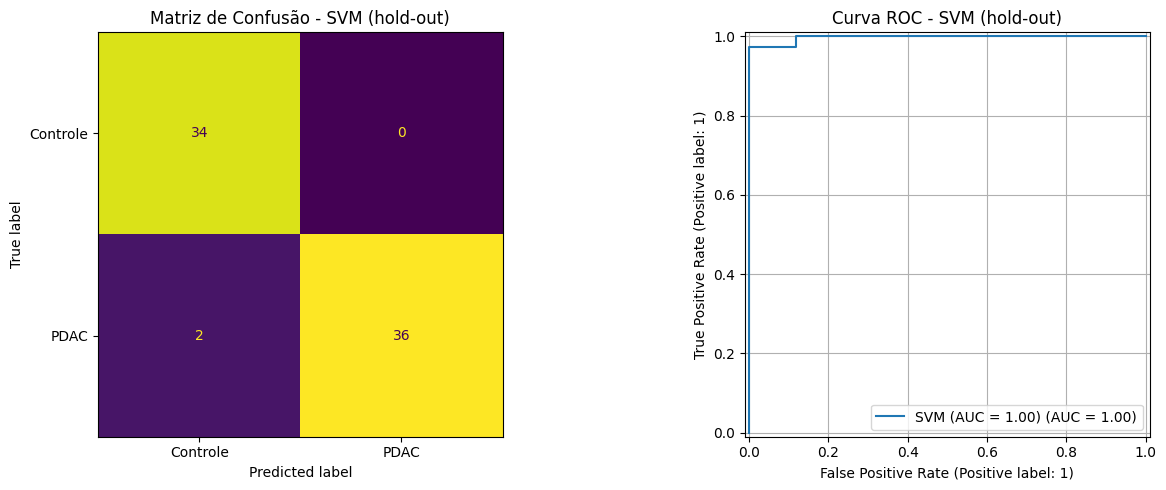

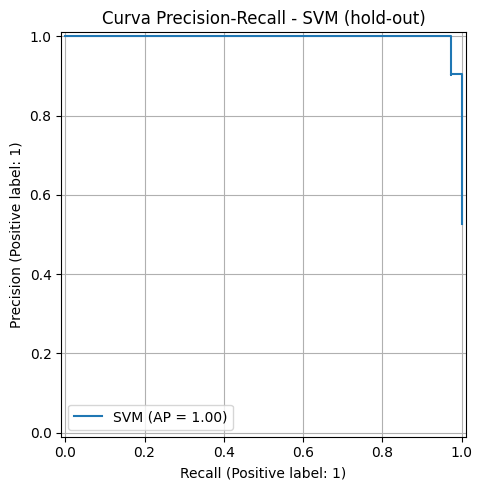

Calculando permutation importance (pode levar alguns segundos)...


c:\Users\cassi\miniconda3\envs\cancer_gpu\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


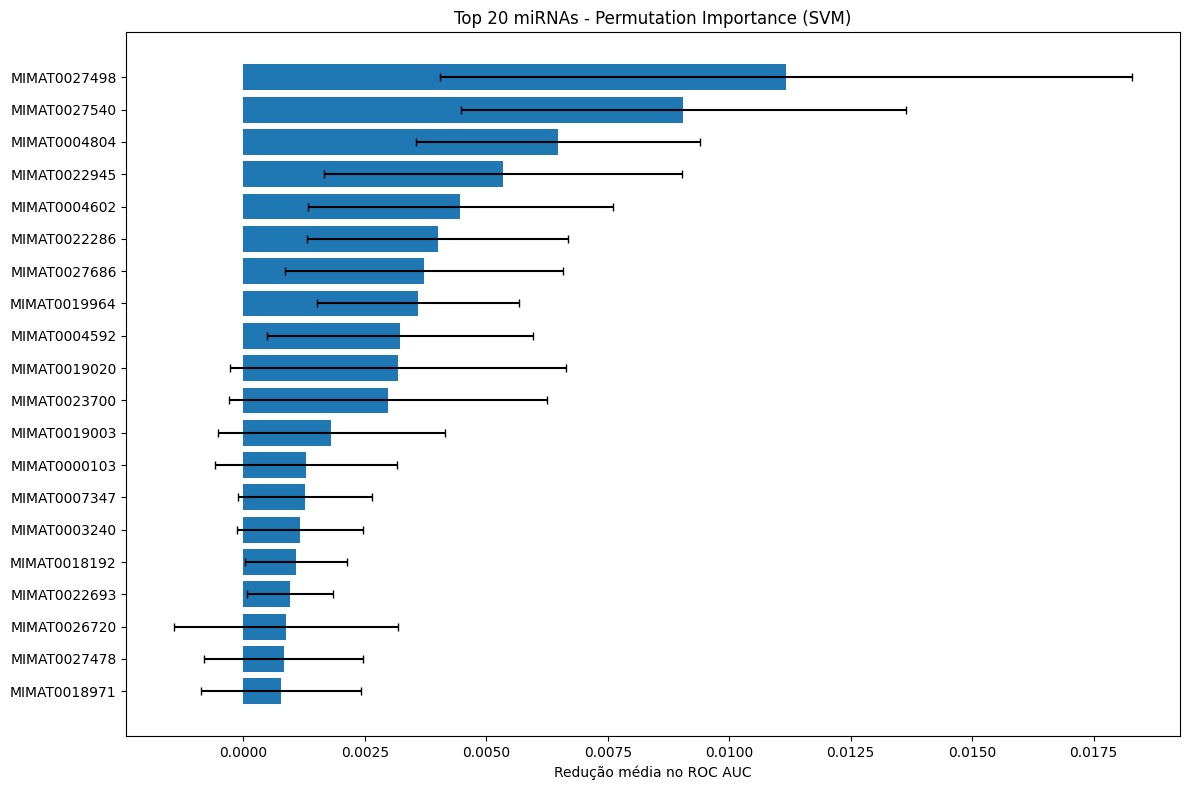

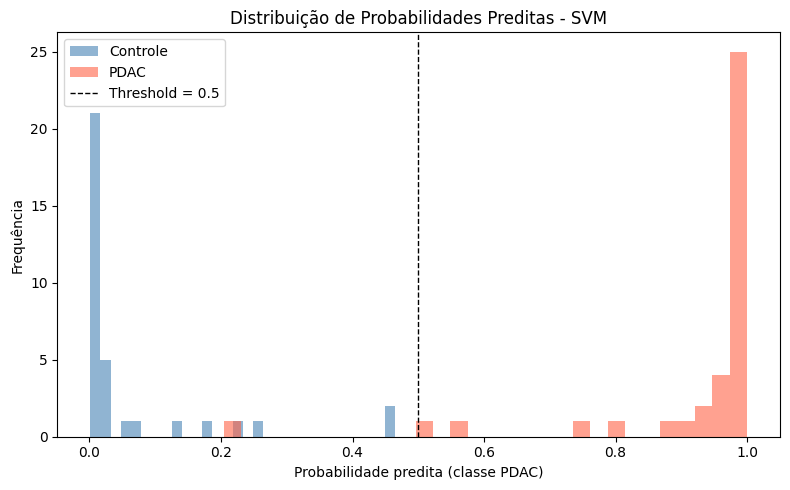

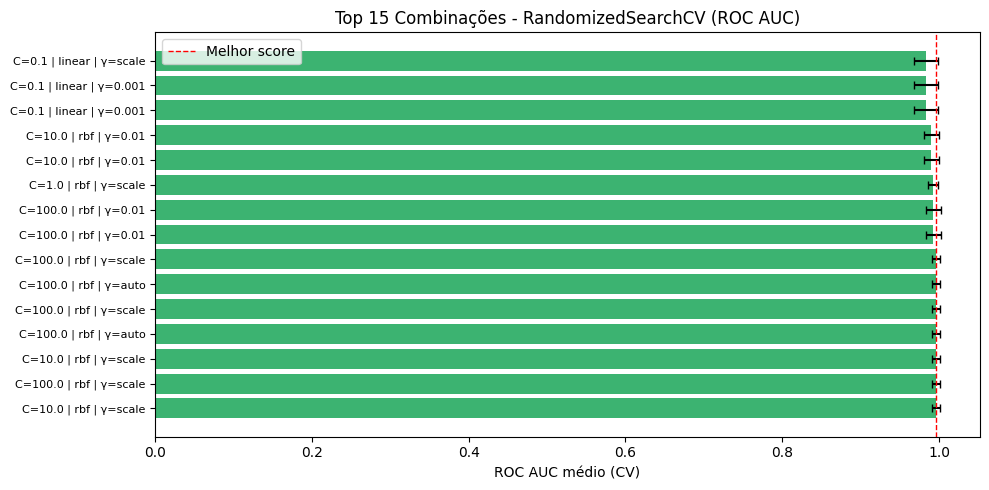

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MATRIZ DE CONFUSÃO
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Controle', 'PDAC'])
disp.plot(cmap='viridis', ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de Confusão - SVM (hold-out)')

# CURVA ROC
auc_score = roc_auc_score(y_test, y_prob)
RocCurveDisplay.from_predictions(y_test, y_prob, name=f'SVM (AUC = {auc_score:.2f})', ax=axes[1])
axes[1].set_title('Curva ROC - SVM (hold-out)')
axes[1].grid(True)

plt.tight_layout()
plt.savefig("plots/svm_confusion_roc.png", dpi=300, bbox_inches="tight")
plt.show()

# CURVA PRECISION-RECALL
fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_prob, name='SVM', ax=ax)
ax.set_title('Curva Precision-Recall - SVM (hold-out)')
ax.grid(True)
plt.tight_layout()
plt.savefig("plots/svm_precision_recall.png", dpi=300, bbox_inches="tight")
plt.show()

# IMPORTÂNCIA DAS FEATURES VIA PERMUTATION IMPORTANCE
print("Calculando permutation importance (pode levar alguns segundos)...")
perm = permutation_importance(best_model, X_test, y_test, n_repeats=30, scoring='roc_auc', random_state=42, n_jobs=-1)

feat_names = dados_test.drop(columns=['sample_id', 'target', 'split']).columns
perm_df = pd.DataFrame({
    "miRNA": feat_names,
    "importance_mean": perm.importances_mean,
    "importance_std":  perm.importances_std
}).sort_values("importance_mean", ascending=False)

top20_perm = perm_df.head(20)
top20_perm.to_csv("plots/Top20_miRNAs_SVM_permutation.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top20_perm["miRNA"], top20_perm["importance_mean"],
        xerr=top20_perm["importance_std"], align='center', capsize=3)
ax.invert_yaxis()
ax.set_title("Top 20 miRNAs - Permutation Importance (SVM)")
ax.set_xlabel("Redução média no ROC AUC")
plt.tight_layout()
plt.savefig("plots/svm_permutation_importance.png", dpi=300, bbox_inches="tight")
plt.show()

# DISTRIBUIÇÃO DOS SCORES DE PROBABILIDADE
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(y_prob[y_test == 0], bins=30, alpha=0.6, label='Controle', color='steelblue')
ax.hist(y_prob[y_test == 1], bins=30, alpha=0.6, label='PDAC',     color='tomato')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Threshold = 0.5')
ax.set_title('Distribuição de Probabilidades Preditas - SVM')
ax.set_xlabel('Probabilidade predita (classe PDAC)')
ax.set_ylabel('Frequência')
ax.legend()
plt.tight_layout()
plt.savefig("plots/svm_prob_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# RESULTADOS DO GRIDSEARCH — TOP 15 COMBINAÇÕES
results_df = pd.DataFrame(search.cv_results_)
top15 = (results_df[['param_svc__kernel', 'param_svc__C', 'param_svc__gamma',
                       'mean_test_score', 'std_test_score', 'rank_test_score']]
           .sort_values('rank_test_score')
           .head(15)
           .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top15.index[::-1],
        top15['mean_test_score'][::-1],
        xerr=top15['std_test_score'][::-1],
        align='center', capsize=3, color='mediumseagreen')
ax.set_yticks(top15.index[::-1])
ax.set_yticklabels([f"C={r.param_svc__C} | {r.param_svc__kernel} | γ={r.param_svc__gamma}"
                    for _, r in top15[::-1].iterrows()], fontsize=8)
ax.set_title('Top 15 Combinações - RandomizedSearchCV (ROC AUC)')
ax.set_xlabel('ROC AUC médio (CV)')
ax.axvline(top15['mean_test_score'].max(), color='red', linestyle='--', linewidth=1, label='Melhor score')
ax.legend()
plt.tight_layout()
plt.savefig("plots/svm_gridsearch_top15.png", dpi=300, bbox_inches="tight")
plt.show()

Modelo SVM carregado com sucesso!

Realizando inferência...

Sample ID          : GSM2278627
Classe real        : PDAC
Classe prevista    : PDAC
Probabilidade PDAC : 0.8059


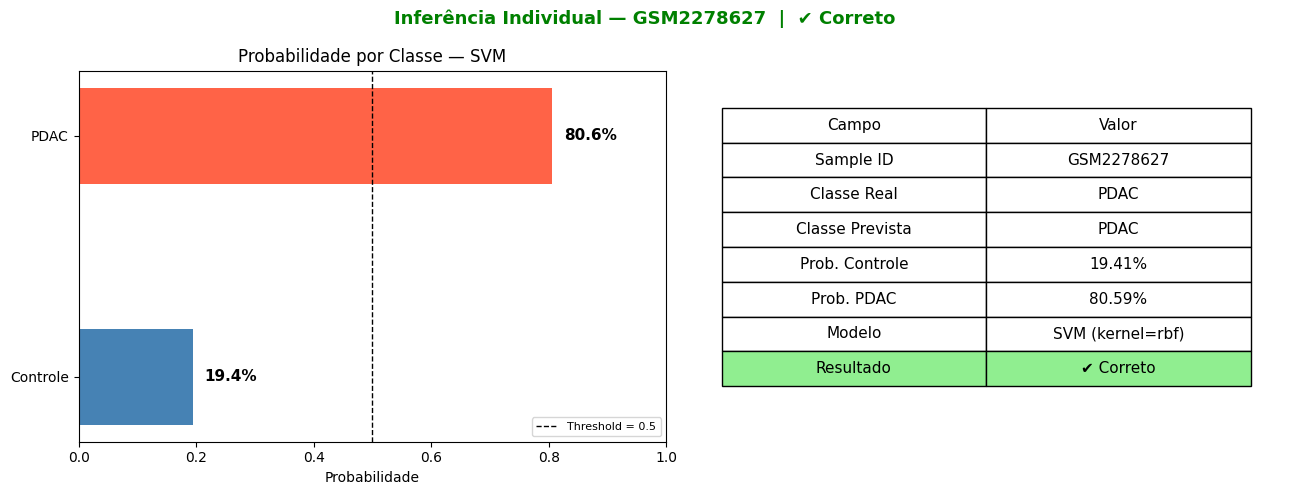

In [ ]:
# CARREGAR MODELO
best_model = load("models_SVM/modelo_SVM.joblib")
print("Modelo SVM carregado com sucesso!")

# CARREGAR BASE DE TESTE
dados_teste = pd.read_csv("../Databases/base_teste_boruta.csv")

# SELECIONAR PACIENTE ALEATÓRIO
paciente = dados_teste.sample(1, random_state=random.randint(1, 10000))

sample_id   = paciente["sample_id"].iloc[0]
classe_real = paciente["target"].iloc[0]

# REMOVER COLUNAS QUE NÃO ENTRAM NO MODELO
paciente_df = paciente.drop(columns=["sample_id", "target", "split"])
paciente_df = paciente_df.fillna(paciente_df.mean())

# INFERÊNCIA
# O pipeline já aplica StandardScaler internamente — não precisa de normalizador externo
print("\nRealizando inferência...\n")
proba = best_model.predict_proba(paciente_df)[0][1]
pred  = best_model.predict(paciente_df)[0]
label_map = {0: "Controle", 1: "PDAC"}

print(f"Sample ID          : {sample_id}")
print(f"Classe real        : {label_map[classe_real]}")
print(f"Classe prevista    : {label_map[pred]}")
print(f"Probabilidade PDAC : {proba:.4f}")

# GRÁFICO
acerto     = (pred == classe_real)
cor_título = "green" if acerto else "red"
status     = "✔ Correto" if acerto else "✘ Incorreto"

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Inferência Individual — {sample_id}  |  {status}",
             fontsize=13, fontweight='bold', color=cor_título)

# SUBPLOT 1: barras de probabilidade
ax = axes[0]
bars = ax.barh(["Controle", "PDAC"], [1 - proba, proba],
               color=["steelblue", "tomato"], height=0.4)
ax.set_xlim(0, 1)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Threshold = 0.5')
ax.set_xlabel("Probabilidade")
ax.set_title("Probabilidade por Classe — SVM")
ax.legend(fontsize=8)

for bar, val in zip(bars, [1 - proba, proba]):
    ax.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
            f"{val:.1%}", va='center', fontsize=11, fontweight='bold')

# SUBPLOT 2: tabela de resumo
ax2 = axes[1]
ax2.axis('off')

# pegar o kernel que foi escolhido pelo RandomizedSearchCV
kernel_usado = best_model.named_steps['svc'].kernel

linhas = [
    ("Sample ID",        str(sample_id)),
    ("Classe Real",      label_map[classe_real]),
    ("Classe Prevista",  label_map[pred]),
    ("Prob. Controle",   f"{(1 - proba) * 100:.2f}%"),
    ("Prob. PDAC",       f"{proba * 100:.2f}%"),
    ("Modelo",           f"SVM (kernel={kernel_usado})"),
    ("Resultado",        status),
]

tabela = ax2.table(
    cellText=linhas,
    colLabels=["Campo", "Valor"],
    cellLoc='center',
    loc='center',
    bbox=[0.05, 0.15, 0.9, 0.75]
)
tabela.auto_set_font_size(False)
tabela.set_fontsize(11)

for col in [0, 1]:
    tabela[len(linhas), col].set_facecolor("lightgreen" if acerto else "lightsalmon")

plt.tight_layout()
plt.savefig(f"plots/inferencia_svm_{sample_id}.png", dpi=300, bbox_inches="tight")
plt.show()